# 11 数据清洗启动笔记（仅方案说明）

本笔记用于启动 NASA 锂离子电池数据清洗与特征选择工作。当前阶段只定义目标、口径和流程，不编写代码。

## 一、项目背景与问题定义

- 数据来源：NASA PCoE 电池老化实验数据。
- 已识别工况：共 9 组（G1-G9），温度与放电策略差异明显。
- 关键挑战：不同组别的 EOL（寿命终止）口径并不一致，存在实验中断、异常低容量循环、截止电压差异等问题。
- 结论：后续建模前必须先完成统一清洗口径，并考虑放弃部分不适合纳入统一训练的组别。

## 二、本阶段目标（数据清洗 + 特征选择前置）

1. 明确可纳入统一建模的数据范围（按组别、按电池逐一确认）。
2. 建立一致的 EOL 定义与样本截断规则。
3. 定义异常样本处理策略（删除、截断或保留并标注）。
4. 给出特征工程候选清单，为后续特征选择做准备。

## 三、EOL 口径统一原则（草案）

- 原则 1：优先采用容量衰减比例定义（例如 20% 或 30% 衰减），并在同一实验中保持一致。
- 原则 2：对于因实验异常提前终止的电池（如软件崩溃导致中断），不直接等同于真实 EOL。
- 原则 3：若组内口径无法统一，优先拆分建模或从主训练集剔除。
- 原则 4：所有保留/剔除决策必须可追溯（记录依据与版本）。

### EOL 比例快速统计代码块（按 G1-G9）

说明：该代码将基于 `data/processed` 中各电池可用容量序列，计算每个电池的容量保持率与容量衰减比例，并按 G1-G9 汇总。

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

def locate_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / 'data' / 'processed').exists():
            return p
    raise FileNotFoundError('未找到 data/processed，请在项目根目录下运行该单元。')

PROJECT_ROOT = locate_project_root(Path.cwd())
PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed'

# 按 README/分组表定义的九组工况映射
GROUP_MAP = {
    'G1': ['B0005', 'B0006', 'B0007', 'B0018'],
    'G2': ['B0025', 'B0026', 'B0027', 'B0028'],
    'G3': ['B0029', 'B0030', 'B0031', 'B0032'],
    'G4': ['B0033', 'B0034', 'B0036'],
    'G5': ['B0038', 'B0039', 'B0040'],
    'G6': ['B0041', 'B0042', 'B0043', 'B0044'],
    'G7': ['B0045', 'B0046', 'B0047', 'B0048'],
    'G8': ['B0049', 'B0050', 'B0051', 'B0052'],
    'G9': ['B0053', 'B0054', 'B0055', 'B0056'],
}

def find_battery_file(battery_id: str) -> Path | None:
    patterns = [f'{battery_id}.pkl', f'{battery_id}.csv', f'{battery_id}.parquet']
    for pat in patterns:
        matches = sorted(PROCESSED_ROOT.rglob(pat))
        if matches:
            return matches[0]
    return None

def load_capacity_series(fp: Path) -> np.ndarray:
    if fp.suffix.lower() == '.pkl':
        obj = pd.read_pickle(fp)
    elif fp.suffix.lower() == '.csv':
        obj = pd.read_csv(fp)
    elif fp.suffix.lower() == '.parquet':
        obj = pd.read_parquet(fp)
    else:
        raise ValueError(f'不支持的文件格式: {fp.suffix}')

    if isinstance(obj, pd.DataFrame):
        df = obj.copy()
        if 'Cycle_Type' in df.columns:
            df = df[df['Cycle_Type'].astype(str).str.lower() == 'discharge']
        cap_col_candidates = [
            'Capacity', 'capacity', 'Discharge_Capacity', 'discharge_capacity'
        ]
        cap_col = next((c for c in cap_col_candidates if c in df.columns), None)
        if cap_col is None:
            raise KeyError(f'{fp.name} 未找到容量列。')
        cap = pd.to_numeric(df[cap_col], errors='coerce').to_numpy()
    elif isinstance(obj, dict):
        cap_key_candidates = [
            'Capacity', 'capacity', 'Discharge_Capacity', 'discharge_capacity'
        ]
        cap_key = next((k for k in cap_key_candidates if k in obj), None)
        if cap_key is None:
            raise KeyError(f'{fp.name} 未找到容量键。')
        cap = pd.to_numeric(pd.Series(obj[cap_key]), errors='coerce').to_numpy()
    else:
        raise TypeError(f'{fp.name} 类型不支持: {type(obj)}')

    cap = cap[np.isfinite(cap)]
    return cap

records = []
for group_name, battery_ids in GROUP_MAP.items():
    for bid in battery_ids:
        fp = find_battery_file(bid)
        if fp is None:
            records.append({
                'group': group_name,
                'battery_id': bid,
                'status': 'file_not_found'
            })
            continue

        try:
            cap = load_capacity_series(fp)
            if len(cap) < 2:
                records.append({
                    'group': group_name,
                    'battery_id': bid,
                    'status': 'insufficient_capacity_points'
                })
                continue

            init_cap = float(cap[0])
            final_cap = float(cap[-1])
            retention_ratio = final_cap / init_cap if init_cap > 0 else np.nan
            fade_ratio = 1.0 - retention_ratio if np.isfinite(retention_ratio) else np.nan

            records.append({
                'group': group_name,
                'battery_id': bid,
                'status': 'ok',
                'file': str(fp.relative_to(PROJECT_ROOT)),
                'n_points': len(cap),
                'init_capacity': init_cap,
                'final_capacity': final_cap,
                'retention_ratio': retention_ratio,
                'fade_ratio': fade_ratio,
                'reached_20pct_fade': bool(fade_ratio >= 0.20),
                'reached_30pct_fade': bool(fade_ratio >= 0.30),
            })
        except Exception as e:
            records.append({
                'group': group_name,
                'battery_id': bid,
                'status': f'error: {e}'
            })

detail_df = pd.DataFrame(records)
detail_df_cn = detail_df.rename(columns={
    'group': '组别',
    'battery_id': '电池编号',
    'status': '状态',
    'file': '文件路径',
    'n_points': '容量点数',
    'init_capacity': '初始容量(Ah)',
    'final_capacity': '末次容量(Ah)',
    'retention_ratio': '容量保持率',
    'fade_ratio': '容量衰减比例',
    'reached_20pct_fade': '是否达到20%衰减',
    'reached_30pct_fade': '是否达到30%衰减',
})
display(detail_df_cn.sort_values(['组别', '电池编号']).reset_index(drop=True))

ok_df = detail_df[detail_df['status'] == 'ok'].copy()
if not ok_df.empty:
    summary_df = ok_df.groupby('group', as_index=False).agg(
        batteries=('battery_id', 'count'),
        mean_retention_ratio=('retention_ratio', 'mean'),
        mean_fade_ratio=('fade_ratio', 'mean'),
        pct_reached_20pct_fade=('reached_20pct_fade', 'mean'),
        pct_reached_30pct_fade=('reached_30pct_fade', 'mean')
    )
    summary_df['pct_reached_20pct_fade'] *= 100.0
    summary_df['pct_reached_30pct_fade'] *= 100.0

    summary_df_cn = summary_df.rename(columns={
        'group': '组别',
        'batteries': '电池数量',
        'mean_retention_ratio': '平均容量保持率',
        'mean_fade_ratio': '平均容量衰减比例',
        'pct_reached_20pct_fade': '达到20%衰减比例(%)',
        'pct_reached_30pct_fade': '达到30%衰减比例(%)',
    })
    display(summary_df_cn.sort_values('组别').reset_index(drop=True))
else:
    print('没有可用于统计的电池记录，请先检查 processed 数据格式。')



,组别,电池编号,状态,文件路径,容量点数,初始容量(Ah),末次容量(Ah),容量保持率,容量衰减比例,是否达到20%衰减,是否达到30%衰减
0,G1,B0005,ok,data\processed\1. BatteryAgingARC-FY08Q4\B0005...,168,1.856487,1.325079,0.713756,0.286244,True,False
1,G1,B0006,ok,data\processed\1. BatteryAgingARC-FY08Q4\B0006...,168,2.035338,1.185675,0.582545,0.417455,True,True
2,G1,B0007,ok,data\processed\1. BatteryAgingARC-FY08Q4\B0007...,168,1.891052,1.432455,0.757491,0.242509,True,False
3,G1,B0018,ok,data\processed\1. BatteryAgingARC-FY08Q4\B0018...,132,1.855005,1.341051,0.722937,0.277063,True,False
4,G2,B0025,ok,data\processed\2. BatteryAgingARC_25_26_27_28_...,28,1.847011,1.767789,0.957108,0.042892,False,False
5,G2,B0026,ok,data\processed\2. BatteryAgingARC_25_26_27_28_...,28,1.813250,1.768754,0.975460,0.024540,False,False
6,G2,B0027,ok,data\processed\2. BatteryAgingARC_25_26_27_28_...,28,1.823308,1.770093,0.970814,0.029186,False,False
7,G2,B0028,ok,data\processed\2. BatteryAgingARC_25_26_27_28_...,28,1.804685,1.717234,0.951542,0.048458,False,False
8,G3,B0029,ok,data\processed\3. BatteryAgingARC_25-44\B0029.pkl,40,1.697507,1.612080,0.949675,0.050325,False,False
9,G3,B0030,ok,data\processed\3. BatteryAgingARC_25-44\B0030.pkl,40,1.656071,1.562780,0.943668,0.056332,False,False


,组别,电池数量,平均容量保持率,平均容量衰减比例,达到20%衰减比例(%),达到30%衰减比例(%)
0,G1,4,0.694182,0.305818,100.0,25.0
1,G2,4,0.963731,0.036269,0.0,0.0
2,G3,4,0.963302,0.036698,0.0,0.0
3,G4,3,7.498134,-6.498134,0.0,0.0
4,G5,3,4.526868,-3.526868,0.0,0.0
5,G6,4,4.324609,-3.324609,75.0,0.0
6,G7,4,0.664288,0.335712,100.0,75.0
7,G8,4,0.937861,0.062139,25.0,25.0
8,G9,4,0.669445,0.330555,50.0,50.0


## 四、组别处理策略（初步假设，待验证）

- G1-G4：室温/高温主体组，优先作为主干数据。
- G5：跨温度组（24C 与 44C），需评估是否拆组后再纳入。
- G6-G9：低温组（4C）整体分布偏移明显，需单独评估。
- 可能优先剔除对象：样本量不足或终止机制不可靠的组别（如中断组）。
- 说明：最终剔除名单必须基于数据统计与可视化证据，不凭经验直接决定。

C:\Users\PLUTO\AppData\Local\Temp\ipykernel_1756\422099827.py:115: UserWarning: Glyph 24490 (\N{CJK UNIFIED IDEOGRAPH-5FAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_1756\422099827.py:115: UserWarning: Glyph 29615 (\N{CJK UNIFIED IDEOGRAPH-73AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_1756\422099827.py:115: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_1756\422099827.py:115: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_1756\422099827.py:115: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PLUTO\AppData\Local\Temp\ipykernel_1756\422099827.py:115: UserWarning: Glyph 37327 (\N{CJK 

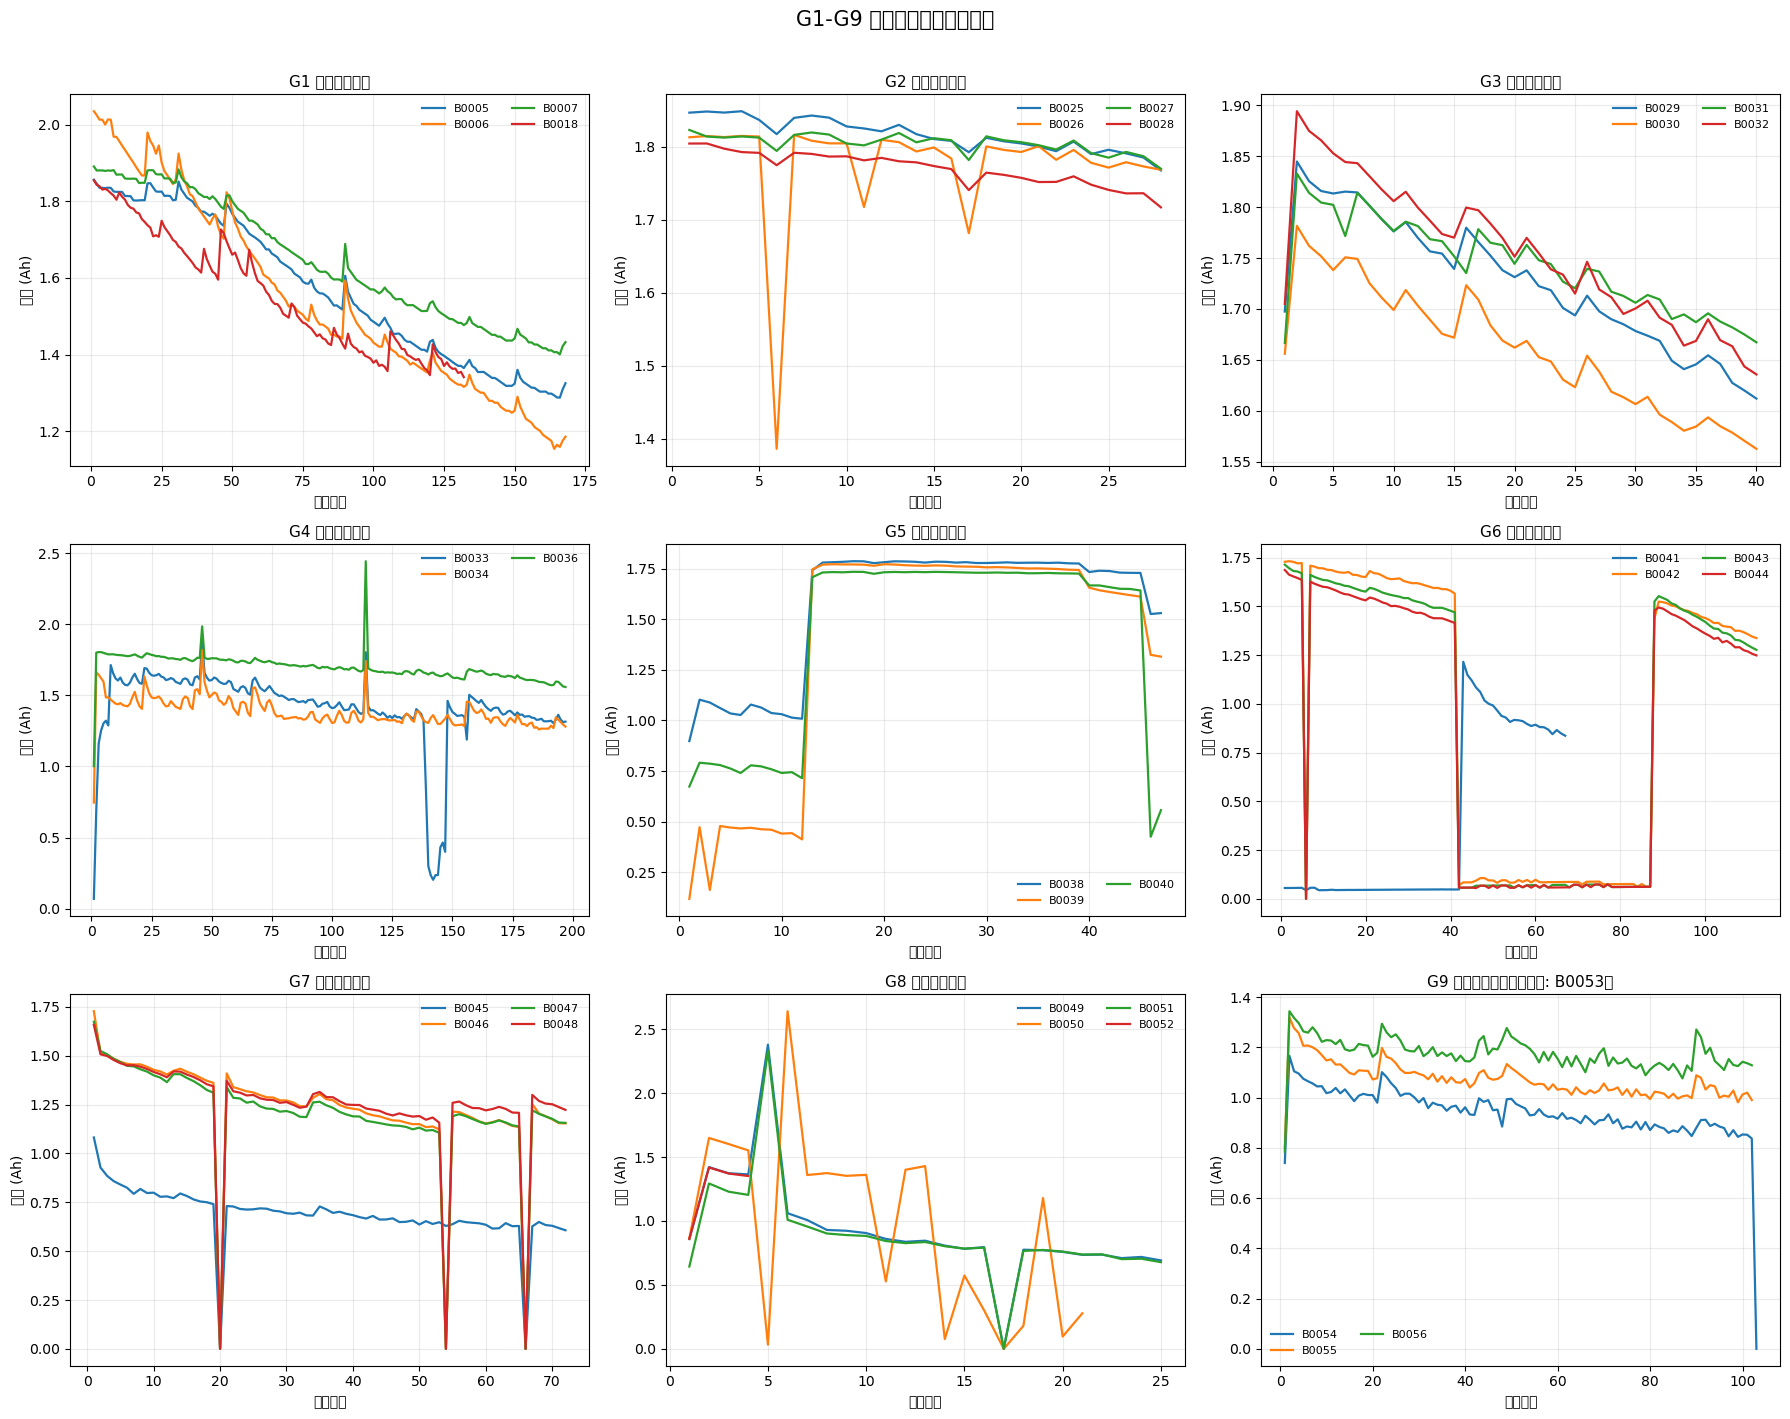

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

def setup_chinese_font():
    candidates = [
        'Microsoft YaHei',
        'SimHei',
        'Noto Sans CJK SC',
        'Source Han Sans SC',
        'PingFang SC',
        'WenQuanYi Zen Hei',
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams['font.sans-serif'] = [name]
            plt.rcParams['axes.unicode_minus'] = False
            return name
    plt.rcParams['axes.unicode_minus'] = False
    return None

selected_font = setup_chinese_font()
if selected_font is None:
    print('未找到常见中文字体，图中中文可能显示异常。')
else:
    print(f'中文字体已设置为: {selected_font}')

def locate_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / 'data' / 'processed').exists():
            return p
    raise FileNotFoundError('未找到 data/processed，请在项目根目录下运行该单元。')

PROJECT_ROOT = locate_project_root(Path.cwd())
PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed'

GROUP_MAP = {
    'G1': ['B0005', 'B0006', 'B0007', 'B0018'],
    'G2': ['B0025', 'B0026', 'B0027', 'B0028'],
    'G3': ['B0029', 'B0030', 'B0031', 'B0032'],
    'G4': ['B0033', 'B0034', 'B0036'],
    'G5': ['B0038', 'B0039', 'B0040'],
    'G6': ['B0041', 'B0042', 'B0043', 'B0044'],
    'G7': ['B0045', 'B0046', 'B0047', 'B0048'],
    'G8': ['B0049', 'B0050', 'B0051', 'B0052'],
    'G9': ['B0053', 'B0054', 'B0055', 'B0056'],
}

# 根据当前决策，G9 去掉 B0053
EXCLUDE_BY_GROUP = {
    'G9': {'B0053'}
}

def find_battery_file(battery_id: str) -> Path | None:
    patterns = [f'{battery_id}.pkl', f'{battery_id}.csv', f'{battery_id}.parquet']
    for pat in patterns:
        matches = sorted(PROCESSED_ROOT.rglob(pat))
        if matches:
            return matches[0]
    return None

def load_discharge_capacity_series(fp: Path) -> np.ndarray:
    if fp.suffix.lower() == '.pkl':
        obj = pd.read_pickle(fp)
    elif fp.suffix.lower() == '.csv':
        obj = pd.read_csv(fp)
    elif fp.suffix.lower() == '.parquet':
        obj = pd.read_parquet(fp)
    else:
        raise ValueError(f'不支持的文件格式: {fp.suffix}')

    if isinstance(obj, pd.DataFrame):
        df = obj.copy()
        if 'Cycle_Type' in df.columns:
            df = df[df['Cycle_Type'].astype(str).str.lower() == 'discharge']
        cap_col_candidates = [
            'Capacity', 'capacity', 'Discharge_Capacity', 'discharge_capacity'
        ]
        cap_col = next((c for c in cap_col_candidates if c in df.columns), None)
        if cap_col is None:
            raise KeyError(f'{fp.name} 未找到容量列。')
        cap = pd.to_numeric(df[cap_col], errors='coerce').to_numpy()
    elif isinstance(obj, dict):
        cap_key_candidates = [
            'Capacity', 'capacity', 'Discharge_Capacity', 'discharge_capacity'
        ]
        cap_key = next((k for k in cap_key_candidates if k in obj), None)
        if cap_key is None:
            raise KeyError(f'{fp.name} 未找到容量键。')
        cap = pd.to_numeric(pd.Series(obj[cap_key]), errors='coerce').to_numpy()
    else:
        raise TypeError(f'{fp.name} 类型不支持: {type(obj)}')

    cap = cap[np.isfinite(cap)]
    return cap

fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=False, sharey=False)
axes = axes.ravel()

for i, group_name in enumerate(sorted(GROUP_MAP.keys())):
    ax = axes[i]
    battery_ids = GROUP_MAP[group_name]
    excluded = EXCLUDE_BY_GROUP.get(group_name, set())

    plotted = 0
    for bid in battery_ids:
        if bid in excluded:
            continue
        fp = find_battery_file(bid)
        if fp is None:
            continue
        try:
            cap = load_discharge_capacity_series(fp)
            if len(cap) < 2:
                continue
            cycles = np.arange(1, len(cap) + 1)
            ax.plot(cycles, cap, linewidth=1.6, label=bid)
            plotted += 1
        except Exception:
            continue

    title_suffix = ''
    if excluded:
        title_suffix = f'（已排除: {", ".join(sorted(excluded))}）'
    ax.set_title(f'{group_name} 放电容量曲线{title_suffix}', fontsize=11)
    ax.set_xlabel('循环次数')
    ax.set_ylabel('容量 (Ah)')
    ax.grid(alpha=0.25)

    if plotted > 0:
        ax.legend(fontsize=8, ncol=2, frameon=False)
    else:
        ax.text(0.5, 0.5, '无可用数据', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('G1-G9 组别放电容量曲线对比', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 五、数据清洗

本节给出一套“文献可解释 + 面向当前数据现实”的清洗套路。目标是：在不破坏真实退化趋势的前提下，去掉明显非物理异常与不可比样本，为后续深度学习建模提供稳定输入。

### 5.1 清洗对象与统一口径

- 清洗对象：仅保留 G1（室温）、G3（高温）、G9（低温）三组。
- 额外约束：G9 固定排除 B0053。
- EOL 统一口径：容量相对初始容量衰减 30%（即容量保持率 <= 70%）。
- 不纳入组别（G2/G4/G5/G6/G7/G8）暂不处理，原因是异构负载和异常模式过重，会显著增加清洗不确定性。

### 5.2 文献启发与本项目落地逻辑

- 文献中普遍指出：电池早期循环可能出现容量回升（formation/活化相关），因此不能简单把所有回升当噪声抹平。
- 同时，RUL 任务要求退化轨迹可学习，必须抑制“突发跳变、异常断崖、非物理点”对时序建模的破坏。
- 因此本项目采用“分层清洗”而不是“一刀切平滑”：先做硬规则剔除，再做弱规则修复，最后保留可解释回升。

### 5.3 总体策略（先严后松）

1. 硬规则层（必须执行）：删除不可用点与不可比样本。
2. 弱规则层（条件执行）：仅修复明显非物理突变，不抹除真实退化细节。
3. 审计层（必须输出）：每个电池记录“删了什么、为什么删、删了多少”，确保可复现。

这套策略的核心是：宁可保留“看起来不平滑但合理”的真实老化信息，也不把模型训练成只会拟合被过度清洗的理想曲线。

### 5.4 分组定制清洗方案（G1 / G3 / G9）

#### G1（室温组，主干基线）
- 预期特征：整体单调衰减，局部噪声较小。
- 清洗原则：轻清洗。
- 处理重点：删除缺失/重复/非数值点；极少数尖峰做邻域修复；保留原始衰减斜率。

#### G3（高温组，退化更快）
- 预期特征：衰减更快、局部波动更明显，早期可能出现回升。
- 清洗原则：中等强度清洗。
- 处理重点：区分“早期可解释回升”与“异常跳变”；对单周期大幅上冲/下坠且快速回归的点执行修复；末段接近 EOL 的区间避免过度修饰。

#### G9（低温组，复杂度最高）
- 预期特征：低温极化更强，回升/波动更频繁。
- 清洗原则：稳健清洗 + 严格审计。
- 处理重点：固定排除 B0053；连续异常段优先截段或标注，不强行插值；单点异常可修复，但跨多周期异常平台应视为工况异常证据。

### 5.5 关于“初始容量回升”的专门处理

- 不直接全删：初期回升在文献和工程实践中经常与形成过程相关。
- 也不全留：若回升幅度/速度明显超过物理可接受范围，则视为异常。
- 判据采用“双门限”：
  - 幅度门限：相邻循环容量增幅超过阈值。
  - 持续门限：区分孤立尖峰还是连续形成新平台。

解释上可区分为：可保留回升（缓慢、连续、幅度有限）与需修复回升（尖峰式、孤立式、回弹式）。

### 5.6 为什么这套清洗方案“足够好”

- 与任务一致：RUL 预测的核心是保留可学习退化轨迹，而非追求视觉平滑。
- 与数据一致：NASA 这批数据工况异构强、EOL口径不一，统一口径 + 分组定制是必要条件。
- 与样本规模一致：当前有效组别不多，过强清洗会丢信息，过弱清洗会放大异常，分层策略可以平衡。
- 与论文写作一致：每一步都有“规则 + 原因 + 影响”，可直接写入方法章节与附录。

### 5.7 下一步执行顺序（仅说明，不写代码）

1. 先固化硬规则清单和弱规则阈值。
2. 对 G1/G3/G9 生成清洗前后对比图与删点统计表。
3. 核对 EOL=30% 下每个电池的有效寿命区间。
4. 输出最终可建模样本清单（含排除原因）。

### 5.8 参考依据（用于论文方法合理性说明）

- Severson et al., Nature Energy (2019): 强调早期循环信息与寿命预测关系。DOI: 10.1038/s41560-019-0356-8
- Yao et al., Frontiers in Energy Research (2022): 指出早期容量回升现象存在，特征工程需兼顾物理意义与稳健性。DOI: 10.3389/fenrg.2022.1059126
- Hu et al., Joule (2020): 电池寿命预测综述，支持“噪声抑制 + 物理可解释特征 + 小样本稳健建模”路线。DOI: 10.1016/j.joule.2019.11.018
- NASA PCoE Battery Dataset README: 明确该数据存在工况异构、EOL标准差异与异常低容量循环，支持采用分组与审计式清洗。

中文字体已设置为: Microsoft YaHei


,电池编号,状态,清洗前点数,清洗后点数,删除无效点数,修复尖峰点数,数据保留率(%)
0,B0005,ok,168,168,0,2,100.0
1,B0006,ok,168,168,0,6,100.0
2,B0007,ok,168,168,0,2,100.0
3,B0018,ok,132,132,0,8,100.0


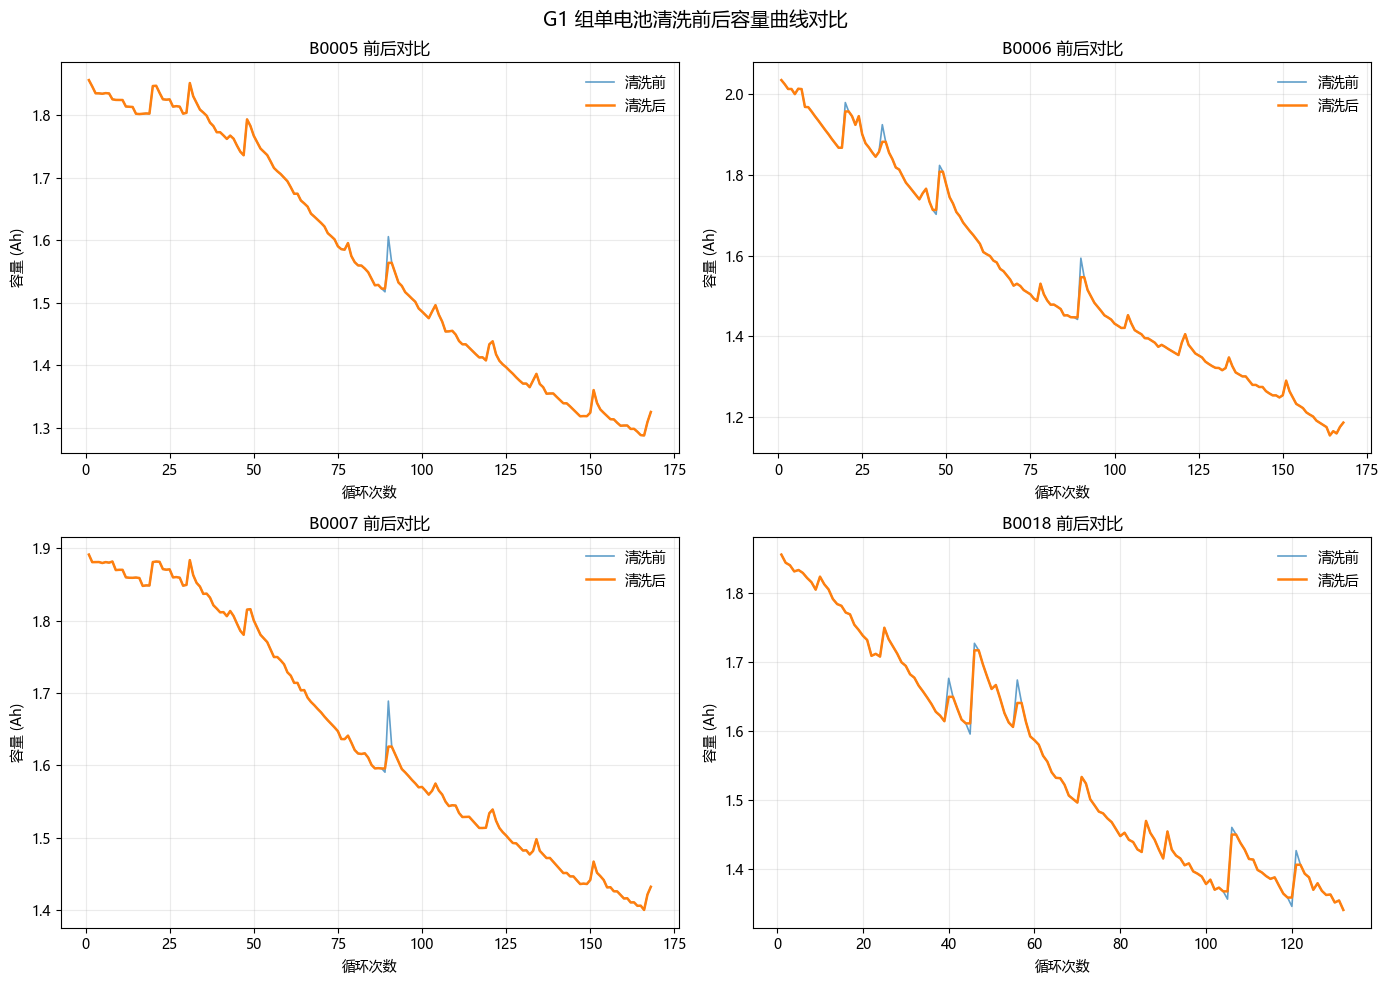

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

def setup_chinese_font():
    candidates = [
        'Microsoft YaHei',
        'SimHei',
        'Noto Sans CJK SC',
        'Source Han Sans SC',
        'PingFang SC',
        'WenQuanYi Zen Hei',
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams['font.sans-serif'] = [name]
            plt.rcParams['axes.unicode_minus'] = False
            return name
    plt.rcParams['axes.unicode_minus'] = False
    return None

selected_font = setup_chinese_font()
if selected_font is None:
    print('未找到常见中文字体，图中中文可能显示异常。')
else:
    print(f'中文字体已设置为: {selected_font}')

# =============================
# G1 轻清洗（符合 5.4 / 5.5 / 5.6 描述）
# 规则：
# 1) 仅处理放电容量序列；
# 2) 删除缺失/非数值/非正容量点；
# 3) 仅修复“孤立尖峰”异常点，不做强平滑。
# =============================

def locate_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / 'data' / 'processed').exists():
            return p
    raise FileNotFoundError('未找到 data/processed，请在项目根目录下运行该单元。')

PROJECT_ROOT = locate_project_root(Path.cwd())
PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed'

G1_BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']

def find_battery_file(battery_id: str) -> Path | None:
    patterns = [f'{battery_id}.pkl', f'{battery_id}.csv', f'{battery_id}.parquet']
    for pat in patterns:
        matches = sorted(PROCESSED_ROOT.rglob(pat))
        if matches:
            return matches[0]
    return None

def read_object(fp: Path):
    suffix = fp.suffix.lower()
    if suffix == '.pkl':
        return pd.read_pickle(fp)
    if suffix == '.csv':
        return pd.read_csv(fp)
    if suffix == '.parquet':
        return pd.read_parquet(fp)
    raise ValueError(f'不支持的文件格式: {fp.suffix}')

def extract_discharge_capacity_raw(obj):
    if isinstance(obj, pd.DataFrame):
        df = obj.copy()
        if 'Cycle_Type' in df.columns:
            df = df[df['Cycle_Type'].astype(str).str.lower() == 'discharge']
        cap_col_candidates = ['Capacity', 'capacity', 'Discharge_Capacity', 'discharge_capacity']
        cap_col = next((c for c in cap_col_candidates if c in df.columns), None)
        if cap_col is None:
            raise KeyError('未找到容量列。')
        return pd.Series(df[cap_col]).to_numpy()

    if isinstance(obj, dict):
        cap_key_candidates = ['Capacity', 'capacity', 'Discharge_Capacity', 'discharge_capacity']
        cap_key = next((k for k in cap_key_candidates if k in obj), None)
        if cap_key is None:
            raise KeyError('未找到容量键。')
        return pd.Series(obj[cap_key]).to_numpy()

    raise TypeError(f'对象类型不支持: {type(obj)}')

def clean_g1_capacity(cap_raw):
    cap_raw = np.asarray(cap_raw).reshape(-1)
    before_points = int(cap_raw.size)

    # 轻清洗第一步：删除非数值与非正容量
    cap_num = pd.to_numeric(pd.Series(cap_raw), errors='coerce').to_numpy()
    finite_mask = np.isfinite(cap_num) & (cap_num > 0)
    cap = cap_num[finite_mask].astype(float)
    removed_invalid = int(before_points - cap.size)

    # 点数不足时直接返回（避免过拟合式修复）
    if cap.size < 5:
        return {
            'before_points': before_points,
            'after_points': int(cap.size),
            'removed_invalid': removed_invalid,
            'repaired_spikes': 0,
            'cap_before': cap.copy(),
            'cap_after': cap.copy(),
        }

    # 轻清洗第二步：仅修复“孤立尖峰”
    cap_before = cap.copy()
    cap_after = cap.copy()

    d = np.diff(cap_before)
    d_med = np.median(d)
    d_mad = np.median(np.abs(d - d_med))
    robust_sigma = 1.4826 * d_mad if d_mad > 0 else 0.0
    jump_th = max(0.03, 6.0 * robust_sigma)

    repaired_idx = []
    for i in range(1, len(cap_after) - 1):
        left = cap_after[i] - cap_after[i - 1]
        right = cap_after[i + 1] - cap_after[i]
        local_dev = abs(cap_after[i] - 0.5 * (cap_after[i - 1] + cap_after[i + 1]))

        # 孤立尖峰判据：前后斜率反向 + 偏离邻域显著
        is_rebound_shape = (left * right) < 0
        is_large_jump = local_dev > jump_th
        if is_rebound_shape and is_large_jump:
            cap_after[i] = np.median([cap_after[i - 1], cap_after[i], cap_after[i + 1]])
            repaired_idx.append(i)

    return {
        'before_points': before_points,
        'after_points': int(cap_after.size),
        'removed_invalid': removed_invalid,
        'repaired_spikes': int(len(repaired_idx)),
        'cap_before': cap_before,
        'cap_after': cap_after,
    }

results = []
series_map = {}

for bid in G1_BATTERIES:
    fp = find_battery_file(bid)
    if fp is None:
        results.append({
            '电池编号': bid,
            '状态': '文件未找到',
            '清洗前点数': np.nan,
            '清洗后点数': np.nan,
            '删除无效点数': np.nan,
            '修复尖峰点数': np.nan,
            '数据保留率(%)': np.nan,
        })
        continue

    try:
        obj = read_object(fp)
        cap_raw = extract_discharge_capacity_raw(obj)
        out = clean_g1_capacity(cap_raw)

        before_points = out['before_points']
        after_points = out['after_points']
        keep_ratio = (after_points / before_points * 100.0) if before_points > 0 else np.nan

        results.append({
            '电池编号': bid,
            '状态': 'ok',
            '清洗前点数': before_points,
            '清洗后点数': after_points,
            '删除无效点数': out['removed_invalid'],
            '修复尖峰点数': out['repaired_spikes'],
            '数据保留率(%)': keep_ratio,
        })

        series_map[bid] = {
            'before': out['cap_before'],
            'after': out['cap_after'],
        }
    except Exception as e:
        results.append({
            '电池编号': bid,
            '状态': f'error: {e}',
            '清洗前点数': np.nan,
            '清洗后点数': np.nan,
            '删除无效点数': np.nan,
            '修复尖峰点数': np.nan,
            '数据保留率(%)': np.nan,
        })

# 1) 输出数据量变化表
summary_df = pd.DataFrame(results)
display(summary_df)

# 2) 绘制单个电池清洗前后对比图（每块子图对应 1 个电池）
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, bid in enumerate(G1_BATTERIES):
    ax = axes[i]
    info = series_map.get(bid)
    if info is None:
        ax.text(0.5, 0.5, '无可用数据', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{bid} 前后对比')
        ax.set_xlabel('循环次数')
        ax.set_ylabel('容量 (Ah)')
        ax.grid(alpha=0.25)
        continue

    cap_before = info['before']
    cap_after = info['after']
    x_before = np.arange(1, len(cap_before) + 1)
    x_after = np.arange(1, len(cap_after) + 1)

    ax.plot(x_before, cap_before, label='清洗前', linewidth=1.2, alpha=0.7)
    ax.plot(x_after, cap_after, label='清洗后', linewidth=1.8)
    ax.set_title(f'{bid} 前后对比')
    ax.set_xlabel('循环次数')
    ax.set_ylabel('容量 (Ah)')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

plt.suptitle('G1 组单电池清洗前后容量曲线对比', fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
from pathlib import Path
import pandas as pd

# 将 G1 清洗结果按电池分别保存到 data/cleaned/G1
PROJECT_ROOT = locate_project_root(Path.cwd())
SAVE_DIR = PROJECT_ROOT / 'data' / 'cleaned' / 'G1'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if 'series_map' not in globals():
    raise RuntimeError('未检测到 series_map，请先运行上一单元（G1 清洗单元）。')

saved_files = []
for bid, item in series_map.items():
    cap_after = item.get('after')
    if cap_after is None or len(cap_after) == 0:
        continue

    out_df = pd.DataFrame({
        'battery_id': bid,
        'cycle_index': range(1, len(cap_after) + 1),
        'capacity_cleaned_ah': cap_after,
    })

    out_path = SAVE_DIR / f'{bid}.csv'
    out_df.to_csv(out_path, index=False, encoding='utf-8-sig')
    saved_files.append(str(out_path.relative_to(PROJECT_ROOT)))

# 同步保存清洗统计表
if 'summary_df' in globals():
    summary_path = SAVE_DIR / 'G1_cleaning_summary.csv'
    summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
    saved_files.append(str(summary_path.relative_to(PROJECT_ROOT)))

print(f'保存目录: {SAVE_DIR}')
print('已保存文件:')
for fp in saved_files:
    print(' -', fp)

保存目录: C:\Users\PLUTO\Desktop\battery-rul\data\cleaned\G1
已保存文件:
 - data\cleaned\G1\B0005.csv
 - data\cleaned\G1\B0006.csv
 - data\cleaned\G1\B0007.csv
 - data\cleaned\G1\B0018.csv
 - data\cleaned\G1\G1_cleaning_summary.csv


## 六、特征选择准备清单（不含代码）

- 候选特征族：容量退化特征、增量容量曲线特征、内阻/阻抗特征、工况上下文特征。
- 特征筛选原则：可解释性、跨工况稳定性、对 RUL 的单调相关性、对异常样本的鲁棒性。
- 评估思路：先做单特征统计，再做组合特征增益比较。

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd


def _locate_project_root(start: Path) -> Path:
    cur = start.resolve()
    for parent in [cur] + list(cur.parents):
        if (parent / 'data' / 'cleaned').exists() or (parent / 'data' / 'processed').exists():
            return parent
    raise FileNotFoundError('未找到项目根目录（缺少 data 目录）。')


project_root = locate_project_root(Path.cwd()) if 'locate_project_root' in globals() else _locate_project_root(Path.cwd())
g1_clean_dir = project_root / 'data' / 'cleaned' / 'G1'
g1_processed_dir = project_root / 'data' / 'processed' / 'G1'

source_dir = g1_clean_dir if g1_clean_dir.exists() else g1_processed_dir
if not source_dir.exists():
    raise FileNotFoundError(f'未找到 G1 数据目录：{g1_clean_dir} 或 {g1_processed_dir}')

files = sorted(source_dir.glob('*.csv'))
if not files:
    raise FileNotFoundError(f'{source_dir} 下没有 CSV 文件。')

frames = []
for fp in files:
    d = pd.read_csv(fp)
    d['__file__'] = fp.name
    frames.append(d)

g1_all = pd.concat(frames, ignore_index=True)
print(f'数据来源: {source_dir}')
print(f'文件数: {len(files)}, 总行数: {len(g1_all)}, 总列数: {g1_all.shape[1]}')

base_cols = {
    'battery_id', 'cell_id', 'cycle', 'cycle_idx',
    'capacity', 'capacity_ah', 'discharge_capacity', 'discharge_capacity_ah',
    '__file__'
}
other_cols = [c for c in g1_all.columns if c not in base_cols]
if not other_cols:
    print('除核心容量相关字段外，没有其余可检查列。')
else:
    rows = []
    for col in other_cols:
        s = g1_all[col]
        missing_ratio = s.isna().mean()

        s_num = pd.to_numeric(s, errors='coerce')
        non_null = s.notna().sum()
        numeric_valid = s_num.notna().sum()
        non_numeric_ratio = ((non_null - numeric_valid) / non_null) if non_null else 0.0

        outlier_ratio = np.nan
        zero_ratio = np.nan
        if numeric_valid >= 10:
            q1, q3 = s_num.quantile(0.25), s_num.quantile(0.75)
            iqr = q3 - q1
            if pd.notna(iqr) and iqr > 0:
                low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                outlier_ratio = ((s_num < low) | (s_num > high)).mean()
            zero_ratio = (s_num == 0).mean()

        need_clean = (
            (missing_ratio > 0.20)
            or (non_numeric_ratio > 0.00)
            or (pd.notna(outlier_ratio) and outlier_ratio > 0.02)
        )

        rows.append({
            'column': col,
            'missing_ratio': missing_ratio,
            'non_numeric_ratio': non_numeric_ratio,
            'outlier_ratio_iqr': outlier_ratio,
            'zero_ratio': zero_ratio,
            'need_cleaning': need_clean
        })

    report = pd.DataFrame(rows).sort_values(
        by=['need_cleaning', 'missing_ratio', 'non_numeric_ratio', 'outlier_ratio_iqr'],
        ascending=[False, False, False, False]
    )

    display_cols = ['column', 'missing_ratio', 'non_numeric_ratio', 'outlier_ratio_iqr', 'zero_ratio', 'need_cleaning']
    print('\nG1 其余数据列清洗检查（建议阈值：缺失>20% / 非数值>0 / 异常值>2%）')
    display(report[display_cols].head(30).style.format({
        'missing_ratio': '{:.2%}',
        'non_numeric_ratio': '{:.2%}',
        'outlier_ratio_iqr': '{:.2%}',
        'zero_ratio': '{:.2%}'
    }))

    todo_cols = report.loc[report['need_cleaning'], 'column'].tolist()
    if todo_cols:
        print('\n建议优先清洗列:')
        print(todo_cols)
    else:
        print('\n其余列暂无明显清洗必要，可先保留。')


## 七、下一步

下一步在本笔记中先补充“组别纳入/剔除判据表”，再进入第一版清洗规则定义。

当前状态：仅文档框架，尚未开始代码实现。